# Neural Style Transfer — Gatys et al. (2015)
Implementation from scratch in PyTorch. Based on the paper:
A Neural Algorithm of Artistic Style — Gatys, Ecker & Bethge (2015)

In [1]:
#importing the necessary libraries and modules

import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import copy
import matplotlib.pyplot as plt
import numpy
from PIL import Image
import torch.nn as nn

device = 'cuda'
print(device)
img_size = (720, 1280)

cuda


In [2]:
#initializing mean and std of ImageNet and constructing the pipeline to convert, resize, and normalize the 
# PIL image. Also, defining a deprocess function to convert a given tensor into image

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform = transforms.Compose([transforms.Resize(img_size), transforms.ToTensor(),
                                transforms.Normalize(mean, std)])

def load_image(path):
    x = Image.open(path)
    x = transform(x)
    y = x.unsqueeze(0)
    y = y.to(device)
    return y

def deprocess(tensor):
    tensor = tensor.squeeze(0)
    std1 = torch.tensor(std).reshape(3, 1, 1).to(device)
    mean1 = torch.tensor(mean).reshape(3, 1, 1).to(device)
    tensor = tensor * std1 + mean1
    tensor = tensor.clamp(0, 1)
    img = transforms.ToPILImage()(tensor)
    return img
    

In [3]:
#importing the model needed for this project - VGG19

vgg = models.vgg19(pretrained = True).features.to(device)

for p in vgg.parameters():
    p.requires_grad = False

vgg = vgg.eval()

/home/divya/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/divya/.local/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [4]:
vgg

#Architecture of VGG. Indices for the required layers:
#                     conv1_1 : 0
#                     conv2_1 : 5
#                     conv3_1 : 10
#                     conv4_1 : 19
#                     conv4_2 : 21
#                     conv5_1 : 28

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [5]:
#A function which takes the image tensor and model as input, and outputs the feature maps corresponding to 
# different layers

def feature_maps(tensor, vgg):
    i = 0
    j = 0
    features = {}
    for layer in vgg:
        tensor = layer(tensor)
        if i == 0 or i == 5 or i == 10 or i == 19:
            j+=1
            features[f"conv{j}_1"] = tensor
        elif i == 21:
            features["conv4_2"] = tensor
        elif i == 28:
            features["conv5_1"] = tensor
            break
        else:
            pass
        i+=1
    
    return features

In [6]:
# Gram Matrix G = F @ F.T
# F is reshaped from (N, H, W) to (N, M) where M = H*W (flattening spatial dims)
# G[i,j] = dot product of filter i and filter j across all spatial positions
# Captures texture statistics — which filters co-activate — with no spatial information

def gram_matrix(tensor):
    tensor = tensor.squeeze(0)
    N, H, W = tensor.shape
    t1 = tensor.reshape(N, H*W)
    t2 = t1 @ t1.T
    return t2

#Content loss, as derived in the paper

def content_loss_fn(F_x, F_c):
    content_loss = 0.5 * nn.MSELoss(reduction = 'sum')(F_x, F_c)
    return content_loss

#Style loss, as derived in the paper

def style_loss_fn(features_x, features_s):
    style_loss = 0
    for layer in features_x:
        if layer == 'conv4_2':
            continue
        gram_x = gram_matrix(features_x[layer])
        gram_s = gram_matrix(features_s[layer])
        _, N, H, W = features_x[layer].shape
        M = H*W
        style_loss += 0.20 * 1/(4*(N**2)*(M**2)) * nn.MSELoss(reduction = 'sum')(gram_x, gram_s)
    
    return style_loss  

def total_loss_fn(content, style, alpha, beta):
    return alpha*content + beta*style


In [7]:
content = load_image('content/africa.jpg')
style = load_image('style/scream.jpg')

content_features = feature_maps(content, vgg)
style_features = feature_maps(style, vgg)
x = content.clone().detach()
x.requires_grad = True

In [8]:
#Optimizer - the paper uses L-BFGS but I use Adam because of its simplicity.

optimizer = torch.optim.Adam([x], lr = 0.01)
alpha = 0.01 # alpha/beta ratio controls style strength — lower alpha/higher beta = more style
beta = 1e7
steps = 3000

# Optimization loop — X (generated image) is the variable, not VGG19's weights
# Gradients flow back through frozen VGG19 to update X's pixel values directly

for i in range(steps):
    optimizer.zero_grad()
    F_c = content_features['conv4_2']
    feature_x = feature_maps(x, vgg)
    content_loss = content_loss_fn(feature_x['conv4_2'], F_c)
    style_loss = style_loss_fn(feature_x, style_features)
    total_loss = total_loss_fn(content_loss, style_loss, alpha, beta)
    total_loss.backward()
    optimizer.step()
    x.data.clamp_(0,1)
    if (i+1) % 50 == 0:
        print(f"{i+1} : {total_loss}")

50 : 1573436.25
100 : 836190.5
150 : 553670.9375
200 : 420792.125
250 : 347528.46875
300 : 300409.3125
350 : 267836.0625
400 : 244795.15625
450 : 227743.875
500 : 218561.0
550 : 202936.0
600 : 190656.953125
650 : 188229.5625
700 : 175927.15625
750 : 168547.140625
800 : 165207.71875
850 : 158444.65625
900 : 170672.8125
950 : 151565.515625
1000 : 150960.5625
1050 : 156419.28125
1100 : 141958.0
1150 : 138706.15625
1200 : 135774.4375
1250 : 145337.015625
1300 : 132801.9375
1350 : 132489.5625
1400 : 127039.0234375
1450 : 132275.03125
1500 : 124314.046875
1550 : 127759.625
1600 : 121322.5
1650 : 119708.375
1700 : 118531.0546875
1750 : 117878.640625
1800 : 118367.46875
1850 : 121342.7890625
1900 : 115142.640625
1950 : 113917.453125
2000 : 114637.921875
2050 : 112336.421875
2100 : 640527.625
2150 : 178220.234375
2200 : 142623.046875
2250 : 130877.828125
2300 : 124710.8125
2350 : 120355.953125
2400 : 117267.984375
2450 : 114395.140625
2500 : 112312.8515625
2550 : 113927.5
2600 : 109288.21875
26

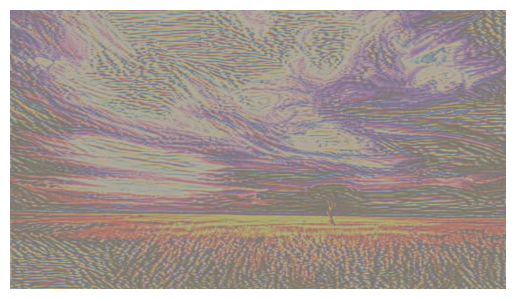

In [9]:
plt.imshow(deprocess(x))
plt.axis('off')
plt.show()

In [10]:
output = deprocess(x)
output.save("output_2.png")